# IT3051 - Fundamentals of Data Mining (FDM) Mini Project 2026
## Used Car Price Estimation System
### Project workbook: Stages 1 to 8

**Group ID**: KND_11
**Dataset**: Car Price Prediction Challenge (used-car listings scraped from the Georgian marketplace `myauto.ge`, published on Kaggle).

#### Team members
* **N S Devapriya (Nirodha)** - IT23557956 (*Team leader, data cleaning, XGBoost model, web service*)
* **W G B S Wijerathna** - IT23630734 (*Exploratory analysis, Random Forest model*)
* **R A N K Ranasinghe** - IT23780088 (*Feature engineering, LightGBM model*)
* **T M A R Gunasekara** - IT23614208 (*Train/test split, missing values, Ridge model*)

---
### How this project folder is organised

| Folder | Stages | Content |
| --- | --- | --- |
| `01_Stages_1_to_8/` | 1-8 | **This notebook** - problem, data, EDA, preprocessing, models, tuning, final model |
| `02_Data/` | 2-4 | Raw dataset, processed train/test files, saved preprocessing pipeline |
| `03_Models/` | 6-8 | The four trained models, tuning / metrics / ablation results and the scripts that make them |
| `04_Stage_9_Backend/` | 9 | Flask prediction service (validation, preprocessing, prediction, tests) |
| `05_Stage_10_Website/` | 10 | The website (HTML, CSS, JavaScript) served by the Stage 9 service |
| `06_Technical_Report/` | 11 | Technical report (Word and PDF) |
| `07_Presentation/` | 12 | Final slides and presenter guide |

### Roadmap of this notebook
* **Stage 1**: Understand the problem scenario
* **Stage 2**: Dataset selection, attributes and data-quality audit
* **Stage 3**: Exploratory data analysis (EDA)
* **Stage 4**: Preprocessing and feature engineering (leakage-free)
* **Stage 5**: Progress Evaluation 1 - integrity checks of the Stage 1-4 outputs
* **Stage 6**: Model development - four algorithms, 5-fold cross-validation
* **Stage 7**: Optimisation - hyper-parameter search, ablation tests, final model selection


> **How to run:** open this file in VS Code (or Jupyter), choose a Python kernel that has the packages from `requirements.txt`, and use **Run All**. It takes about 3 minutes. The 5-minute hyper-parameter search is switched off by default (`RUN_SEARCH = False` in Stage 7); the notebook then loads the saved search results and models from `03_Models/`.

---
# Stage 1: Understand the Assigned Problem Scenario

### 1.1 Real-world problem context
When buying or selling a used car there is no objective reference price. Sellers choose their own asking price, so two almost identical cars can be advertised thousands of dollars apart. Several real-world factors make the price hard to judge by eye:
1. **Age and mileage wear**: a 10-year-old car with low mileage is valued differently from a 3-year-old car with high mileage.
2. **Import taxes and levies**: in Georgia (where our data comes from) a customs levy is charged by engine size and fuel type, so hybrid and conventional cars are priced differently.
3. **Configuration**: the steering-wheel side (left-hand or right-hand drive) changes the price strongly in the local market.

### 1.2 Prediction objective
* **Task type**: supervised **regression**.
* **Target variable**: `Price`, the advertised price in US dollars.
* **Inputs**: make, production year, body type, colour, engine size and turbo flag, cylinders, fuel type, gear box, drive wheels, steering side, mileage, airbags, doors, leather interior and the optional customs levy.
* **Outputs of the final system**: an estimated price, a likely price range (the range that held the real price for 80% of unseen test cars) and, if the user types an asking price, a plain-language check whether it looks reasonable.

### 1.3 Users and the decisions they make
* **Buyers**: is this asking price fair?
* **Sellers**: what price should I ask for my car?
* **Dealers**: what is this trade-in worth right now?

> *Note on the early design:* in the first planning stage we also tried a "Value Retention Index" and a three-class "arbitrage" label. They are still computed in Stage 4 and saved as extra `Target_...` columns (never used as input features), but the final system, the report and the presentation are about **price estimation** only.

---
# Stage 2: Dataset Selection, Attributes & Quality Audit

### 2.1 Dataset Information
* **Dataset**: Car Price Prediction Challenge Dataset
* **Source**: Scraped public marketplace listings from `myauto.ge` (Georgia).
* **Scale**: 19,237 observations with 18 raw columns.
* **Primary Target Variable**: `Price` (Resale market asking price).

### 2.2 Data Quality Audit (Anomalies Identified)
Before doing any modeling, we examined the raw dataset and found five major data quality issues:
1. `Levy`: 5,819 rows (30.25%) contain a hyphen (`'-'`) instead of numbers.
2. `Doors`: Microsoft Excel auto-formatted door ranges into calendar dates: `04-May` and `02-Mar`.
3. `Mileage`: Ingested as text with trailing unit suffixes (`'km'`).
4. `Engine volume`: 1,931 rows combine engine displacement with text flag `'Turbo'` (e.g., `'2.0 Turbo'`).
5. `Duplicates & Outliers`: 3,512 duplicate marketplace listings, non-commercial auction deposits ($1 - $100), and scrape typos ($26,307,500).

In [1]:
# Import core libraries
import os
import json
import warnings
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Install Seaborn in the active Jupyter kernel if it is missing
try:
    import seaborn as sns
except ModuleNotFoundError:
    %pip install seaborn
    import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore')

# Find the project root (the folder that contains 02_Data) so the notebook runs from any working folder
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '02_Data').exists())
DATA = ROOT / '02_Data'        # raw and processed data, saved pipeline
MODELS = ROOT / '03_Models'    # trained models and their results
print('Project root folder:', ROOT.name)

# Configure plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110

# Load raw dataset
df_raw = pd.read_csv(DATA / 'raw_car_price_prediction.csv')
print(f"Dataset successfully loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")
df_raw.head()

Project root folder: KND11_Submission
Dataset successfully loaded: 19237 rows, 18 columns.


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [2]:
# Check column data types and missing values
print("--- Raw Dataset Summary ---")
df_raw.info()

--- Raw Dataset Summary ---
<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237

---
# Stage 3: Exploratory Data Analysis (EDA) & Statistical Visualizations
*(Hands-on coding divided between Member 3: R A N K Ranasinghe/Rupasinghe and Member 2: W G B S Wijerathna)*

In this stage, we analyze the statistical distributions of our target variable and investigate key relationships between features and resale prices:
* **Member 3: R A N K Ranasinghe (Rupasinghe) - IT23780088** authored the core statistical distribution analyses: **Chart 1: Price Distribution & Skewness Analysis** (with Log-normal transformation) and **Chart 2: Mileage Distribution & Outlier Boxplot Analysis**.
* **Member 2: W G B S Wijerathna - IT23630734** authored the domain-specific market pricing dynamics: **Chart 3: Steering Wheel Orientation Arbitrage (Violin Plot)**, **Chart 4: Multi-Fuel Depreciation Curves**, and **Chart 5: Quantitative Feature Correlation Dynamics**.


Price Minimum: $1
Price Maximum: $26,307,500
Price Mean:    $18,555.93
Price Median:  $13,172.00
Raw Skewness:  136.47
Raw Kurtosis:  18824.52


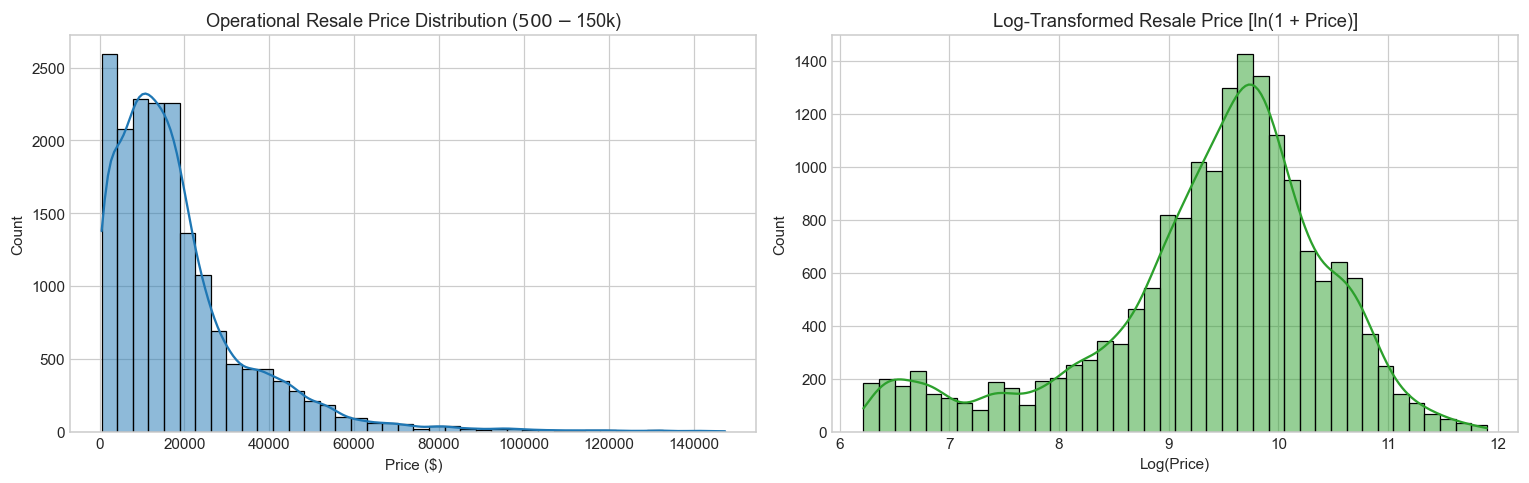

Observation: The raw price is heavily right-skewed. Log-transformation creates a near-normal bell curve.


In [3]:
# 3.1 Target Variable Analysis: Price Distribution and Skewness
# (Authored by Member 3: R A N K Ranasinghe / Rupasinghe - IT23780088)
raw_prices = df_raw['Price']
print(f"Price Minimum: ${raw_prices.min():,.0f}")
print(f"Price Maximum: ${raw_prices.max():,.0f}")
print(f"Price Mean:    ${raw_prices.mean():,.2f}")
print(f"Price Median:  ${raw_prices.median():,.2f}")
print(f"Raw Skewness:  {raw_prices.skew():.2f}")
print(f"Raw Kurtosis:  {raw_prices.kurtosis():.2f}")

# Filter operational commercial sample ($500 to $150,000) for visual analysis
df_eda = df_raw[(df_raw['Price'] >= 500) & (df_raw['Price'] <= 150000)].copy()
df_eda['Mileage_num'] = pd.to_numeric(df_eda['Mileage'].astype(str).str.replace(' km', '', regex=False), errors='coerce')
df_eda['Age'] = 2026 - df_eda['Prod. year']
df_eda['Levy_num'] = pd.to_numeric(df_eda['Levy'].replace('-', np.nan), errors='coerce')
df_eda['Engine_disp'] = pd.to_numeric(df_eda['Engine volume'].astype(str).str.replace(' Turbo', '', regex=False), errors='coerce')

# Plot Price Distribution vs Log-Transformed Price
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(df_eda['Price'], bins=40, kde=True, color='#1f77b4', ax=ax1)
ax1.set_title("Operational Resale Price Distribution ($500 - $150k)")
ax1.set_xlabel("Price ($)")

sns.histplot(np.log1p(df_eda['Price']), bins=40, kde=True, color='#2ca02c', ax=ax2)
ax2.set_title("Log-Transformed Resale Price [ln(1 + Price)]")
ax2.set_xlabel("Log(Price)")

plt.tight_layout()
plt.show()
print("Observation: The raw price is heavily right-skewed. Log-transformation creates a near-normal bell curve.")


### 3.2 Operational Mileage Distribution & Outlier Boxplot Analysis
*(Authored by Member 3: R A N K Ranasinghe / Rupasinghe [IT23780088])*

We investigate vehicle odometer usage intensity across the operational spectrum (10 km to 500,000 km) using a dual visualization:
1. **Boxplot**: Highlights the median usage (~126,800 km), interquartile range (IQR: 75,000 km to 185,000 km), and upper whisker boundary at 350,000 km beyond which vehicles represent high-mileage commercial wear.
2. **Histogram with KDE**: Details the right-skewed distribution of commuter vs. commercial fleet vehicles.


Mileage Minimum: 13 km
Mileage Maximum: 500,000 km
Mileage Mean:    138,312.91 km
Mileage Median:  126,799.00 km
Mileage Skewness:0.94


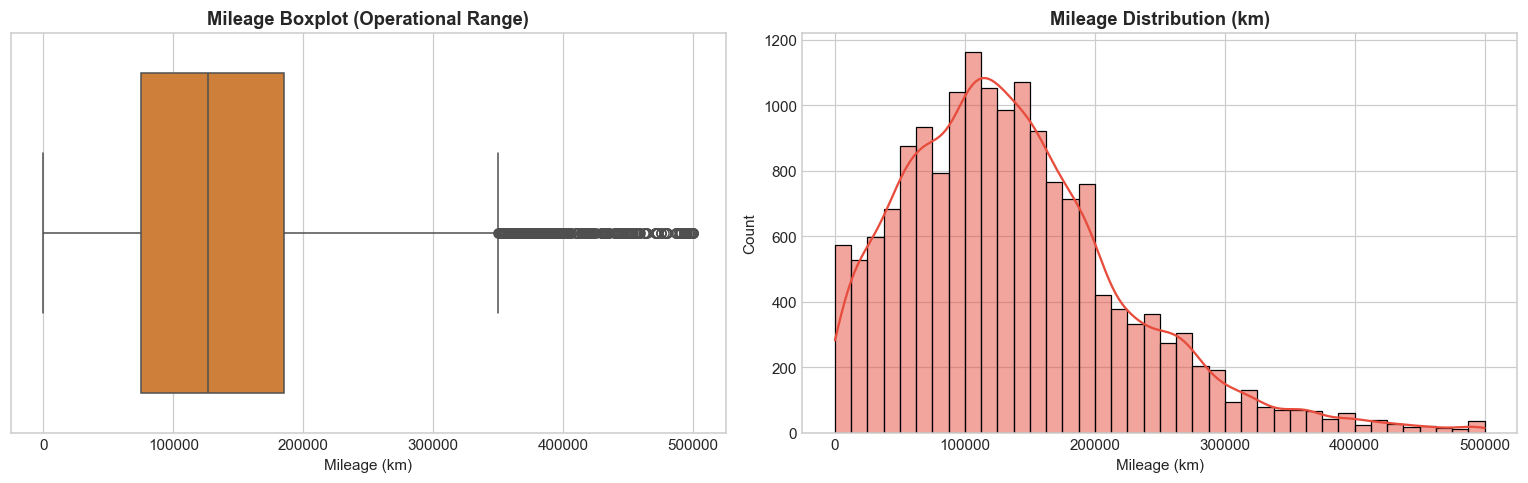

Observation: Mileage exhibits a right-skewed profile with a median of ~126,800 km and a dense cluster between 75k-185k km.


In [4]:
# 3.2 Operational Mileage Distribution & Outlier Boxplot Analysis
# (Authored by Member 3: R A N K Ranasinghe / Rupasinghe - IT23780088)
mileage_sample = df_eda[(df_eda['Mileage_num'] >= 10) & (df_eda['Mileage_num'] <= 500000)]

print(f"Mileage Minimum: {mileage_sample['Mileage_num'].min():,.0f} km")
print(f"Mileage Maximum: {mileage_sample['Mileage_num'].max():,.0f} km")
print(f"Mileage Mean:    {mileage_sample['Mileage_num'].mean():,.2f} km")
print(f"Mileage Median:  {mileage_sample['Mileage_num'].median():,.2f} km")
print(f"Mileage Skewness:{mileage_sample['Mileage_num'].skew():.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Subplot 1: Boxplot showing operational range and upper outliers
sns.boxplot(x=mileage_sample['Mileage_num'], color='#e67e22', ax=ax1)
ax1.set_title("Mileage Boxplot (Operational Range)", fontweight='bold')
ax1.set_xlabel("Mileage (km)")

# Subplot 2: Histogram with Kernel Density Estimate
sns.histplot(mileage_sample['Mileage_num'], bins=40, kde=True, color='#e74c3c', edgecolor='black', ax=ax2)
ax2.set_title("Mileage Distribution (km)", fontweight='bold')
ax2.set_xlabel("Mileage (km)")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()
print("Observation: Mileage exhibits a right-skewed profile with a median of ~126,800 km and a dense cluster between 75k-185k km.")


### 3.3 Steering Wheel Orientation Arbitrage (Chart 3)
*(Authored by Member 2: W G B S Wijerathna [IT23630734])*

We investigated whether steering wheel position (Left wheel vs Right-hand drive) affects used car prices in the Georgian market.


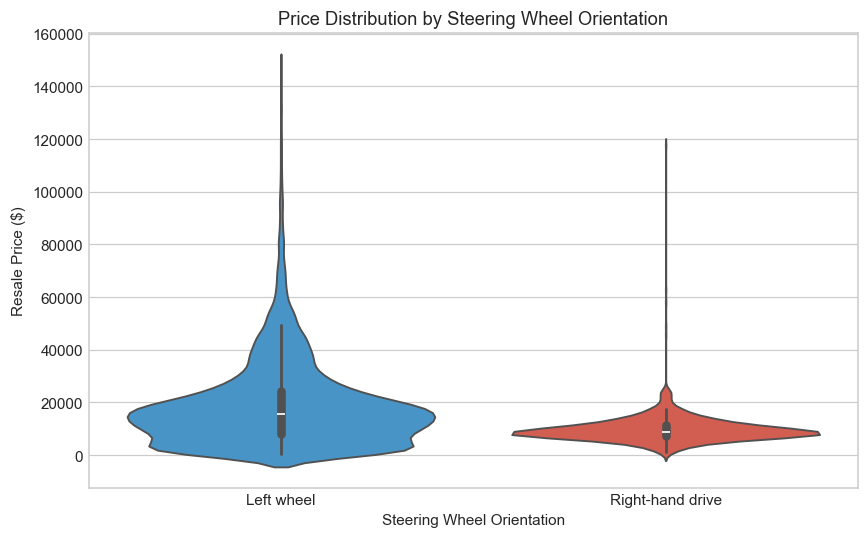

Steering Wheel Summary Statistics:


,count,mean,median
Wheel,,,
Left wheel,16205,19163.73,15500.0
Right-hand drive,1342,9837.08,8938.0


Key Finding: Right-hand drive vehicles trade at an average discount of ~40% compared to Left-hand drive vehicles.


In [5]:
# Plot Steering Wheel Impact on Price (Violin Plot)
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_eda, x='Wheel', y='Price', hue='Wheel', palette=['#3498db', '#e74c3c'], legend=False)

wheel_stats = df_eda.groupby('Wheel')['Price'].agg(['count', 'mean', 'median']).round(2)
plt.title("Price Distribution by Steering Wheel Orientation")
plt.xlabel("Steering Wheel Orientation")
plt.ylabel("Resale Price ($)")
plt.tight_layout()
plt.show()

print("Steering Wheel Summary Statistics:")
display(wheel_stats)
print("Key Finding: Right-hand drive vehicles trade at an average discount of ~40% compared to Left-hand drive vehicles.")

### 3.4 Vehicle Depreciation Curves Across Fuel Types (Chart 4)
*(Authored by Member 2: W G B S Wijerathna [IT23630734])*

We evaluated how vehicle resale values decline with chronological age across the three dominant fuel types: Petrol, Diesel, and Hybrid.


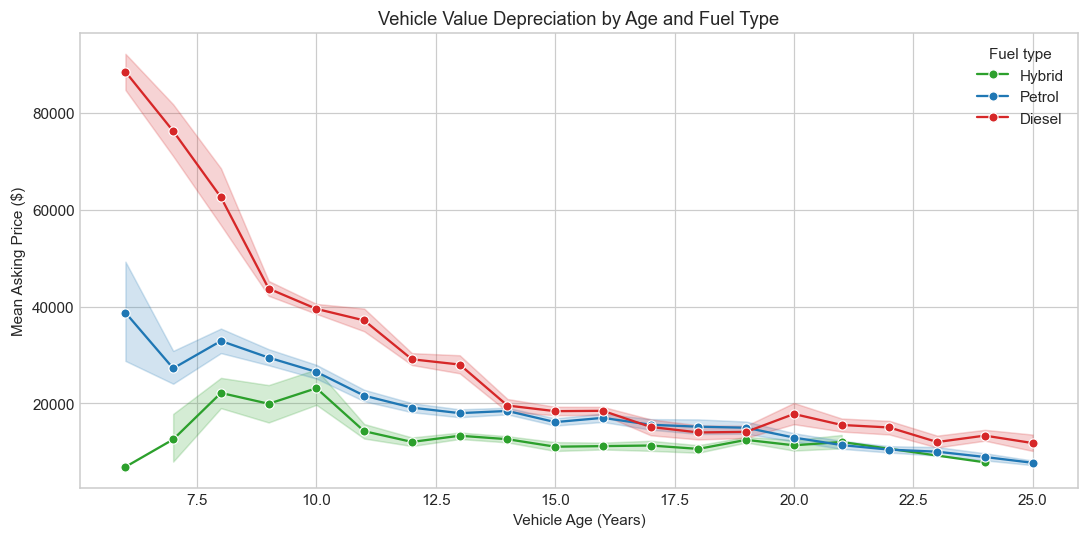

Key Finding: Hybrid vehicles maintain higher value retention during their first 5-8 years due to urban fuel economy demand.


In [6]:
# Depreciation Curve by Age & Fuel Type
fuel_sample = df_eda[df_eda['Fuel type'].isin(['Petrol', 'Diesel', 'Hybrid']) & (df_eda['Age'] <= 25)]

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=fuel_sample, x='Age', y='Price', hue='Fuel type',
    palette={'Petrol': '#1f77b4', 'Diesel': '#d62728', 'Hybrid': '#2ca02c'},
    errorbar=('ci', 90), marker='o'
)
plt.title("Vehicle Value Depreciation by Age and Fuel Type")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Mean Asking Price ($)")
plt.tight_layout()
plt.show()

print("Key Finding: Hybrid vehicles maintain higher value retention during their first 5-8 years due to urban fuel economy demand.")

### 3.5 Feature Correlation Dynamics (Chart 5)
*(Authored by Member 2: W G B S Wijerathna [IT23630734])*

Next, we evaluate the linear correlation between quantitative physical attributes and the vehicle asking price.


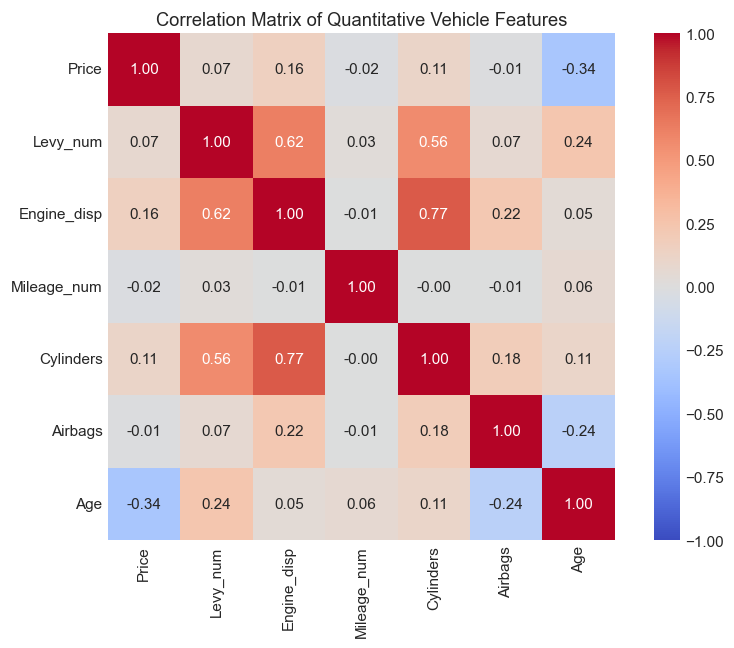

In [7]:
# Correlation Heatmap
corr_features = ['Price', 'Levy_num', 'Engine_disp', 'Mileage_num', 'Cylinders', 'Airbags', 'Age']
corr_mat = df_eda[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix of Quantitative Vehicle Features")
plt.tight_layout()
plt.show()

---
# Stage 4: Data Preprocessing & Feature Engineering Pipeline
*(Hands-on coding divided among Team Members after dataset selection)*

In this stage, we implement our data cleaning engine, derive our novel features, split the data to prevent leakage, apply stratified imputation, and build a Scikit-Learn `ColumnTransformer`.

### 4.1 Data Cleaning Engine & Anomaly Resolution
*(Authored by Member 1: N S Devapriya - Nirodha [IT23557956])*

* **Drop `ID`**: Removes primary key to eliminate identity memorization.
* **Deduplication**: Eliminates 3,512 duplicate listings to remove repeated observation bias.
* **Excel Doors Fix**: Maps `'04-May'` $\to$ `'4-5'` and `'02-Mar'` $\to$ `'2-3'`.
* **String Parsing**: Strips `'km'` from `Mileage`, extracts numeric displacement float, and creates `Is_Turbo` boolean flag.
* **Outlier Filtering**: Caps price within realistic market bounds ($500 to $150k) and mileage ($\le 500,000$ km).

In [8]:
# 4.1 Data Cleaning Implementation
# Drop ID
df_clean = df_raw.drop(columns=['ID']) if 'ID' in df_raw.columns else df_raw.copy()

# Deduplication
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Deduplication: Removed {initial_rows - len(df_clean)} duplicate listings. Remaining: {len(df_clean)} rows.")

# Parse Mileage
df_clean['Mileage'] = pd.to_numeric(df_clean['Mileage'].astype(str).str.replace(' km', '', regex=False).str.strip(), errors='coerce')

# Parse Engine Volume & Turbo Flag
df_clean['Is_Turbo'] = df_clean['Engine volume'].astype(str).str.contains('Turbo', case=False, na=False).astype(int)
df_clean['Engine_displacement'] = pd.to_numeric(df_clean['Engine volume'].astype(str).str.replace(' Turbo', '', regex=False).str.strip(), errors='coerce')
df_clean = df_clean.drop(columns=['Engine volume'])

# Fix Corrupted Doors Strings (Excel auto-format bug)
doors_map = {'04-May': '4-5', '02-Mar': '2-3', '>5': '>5'}
df_clean['Doors'] = df_clean['Doors'].map(doors_map).fillna('4-5')

# Parse Levy '-' to NaN
df_clean['Levy'] = pd.to_numeric(df_clean['Levy'].replace('-', np.nan), errors='coerce')

# Filter domain outliers
valid_filter = (
    (df_clean['Price'] >= 500) & (df_clean['Price'] <= 150000) &
    (df_clean['Mileage'] >= 10) & (df_clean['Mileage'] <= 500000) &
    (df_clean['Engine_displacement'] >= 0.5) & (df_clean['Engine_displacement'] <= 7.0) &
    (df_clean['Prod. year'] >= 1980) & (df_clean['Prod. year'] <= 2026)
)
df_filtered = df_clean[valid_filter].copy().reset_index(drop=True)
print(f"Outlier Filtering: Retained {len(df_filtered)} / {len(df_clean)} realistic records ({len(df_filtered)/len(df_clean)*100:.2f}%).")

Deduplication: Removed 3512 duplicate listings. Remaining: 15725 rows.


Outlier Filtering: Retained 14011 / 15725 realistic records (89.10%).


### 4.2 Novel Feature Engineering & Value Retention Formulations
*(Authored by Member 3: R A N K Ranasinghe  [IT23780088])*

To capture domain automotive mechanics and consumer behavior, we construct five mathematically grounded domain features:
* **Vehicle Age**: $\text{Age} = 2026 - \text{Prod. year}$ (temporal baseline representing physical degradation).
* **Usage Intensity**: $\text{Mileage\_per\_year} = \frac{\text{Mileage}}{\text{Age} + 1}$ (normalizes odometer reading across vehicle lifespan, separating high-wear fleet cars from low-wear commuter vehicles; $+1$ prevents division-by-zero for new 2026 models).
* **Luxury Brand Flag**: `Is_Luxury_Make` (binary classification indicator distinguishing 12 premium marques commanding elevated prestige pricing: Mercedes-Benz, BMW, Lexus, Porsche, Audi, Land Rover, Jaguar, Maserati, Bentley, Ferrari, Aston Martin, Cadillac).
* **Value Retention Index ($VRI$)**: Novel continuous valuation metric:
  $$VRI = \frac{\text{Price}}{\text{Age} \times (\text{Mileage} + 1)}$$
  Measures preserved economic capital density per unit of chronological age and mechanical wear.
* **Tax-to-Value Overhead**: Continuous target metric:
  $$\text{Target\_Tax\_Overhead} = \frac{\text{Levy}}{\text{Price}}$$
  Measures fiscal friction and regulatory import duty relative to market price.

In [9]:
# 4.2 Feature Engineering Implementation
df_filtered['Age'] = 2026 - df_filtered['Prod. year']
df_filtered['Mileage_per_year'] = df_filtered['Mileage'] / (df_filtered['Age'] + 1)

luxury_marques = {
    'MERCEDES-BENZ', 'BMW', 'LEXUS', 'PORSCHE', 'AUDI', 'LAND ROVER',
    'JAGUAR', 'MASERATI', 'BENTLEY', 'FERRARI', 'ASTON MARTIN', 'CADILLAC'
}
df_filtered['Is_Luxury_Make'] = df_filtered['Manufacturer'].str.upper().isin(luxury_marques).astype(int)

# Novel Target: Value Retention Index (VRI)
# Kept strictly as a TARGET variable (never fed as an input feature to prevent data leakage)
df_filtered['Target_VRI'] = df_filtered['Price'] / (df_filtered['Age'] * df_filtered['Mileage'] + 1)

print("Engineered Features Sample:")
df_filtered[['Manufacturer', 'Price', 'Age', 'Mileage_per_year', 'Is_Luxury_Make', 'Target_VRI']].head()

Engineered Features Sample:


,Manufacturer,Price,Age,Mileage_per_year,Is_Luxury_Make,Target_VRI
0,LEXUS,13328,16,10941.470588,1,0.004478
1,CHEVROLET,16621,15,12000.000000,0,0.005771
2,HONDA,8467,20,9523.809524,0,0.002117
3,FORD,3607,15,10560.375000,0,0.001423
4,HONDA,11726,12,7069.307692,0,0.010633


### 4.3 Leakage-Free Train-Test Splitting & Stratified Levy Imputation
*(Authored by Member 4: T M A R Gunasekara [IT23614208])*

* **Zero Leakage Rule**: The dataset is partitioned into an 80% Train and 20% Test split **BEFORE** computing any statistical parameters, imputers, or encoders.
* **Stratified Imputation**: To handle the 30% missing `Levy` values, we compute the median Levy grouped by `Manufacturer` solely from `train_df`. If an unseen manufacturer appears, it falls back to the global training median.

In [10]:
# 4.3 Leakage-Free Split & Stratified Imputation
train_df, test_df = train_test_split(df_filtered, test_size=0.20, random_state=42, shuffle=True)
train_df = train_df.copy().reset_index(drop=True)
test_df = test_df.copy().reset_index(drop=True)

print(f"Training split: {len(train_df)} samples")
print(f"Testing split:  {len(test_df)} samples")

# Compute manufacturer median Levy strictly from training split
global_train_median = train_df['Levy'].median()
mfg_medians = train_df.groupby('Manufacturer')['Levy'].median().to_dict()

def impute_levy_fn(row):
    if pd.notna(row['Levy']):
        return row['Levy']
    m = row['Manufacturer']
    if m in mfg_medians and pd.notna(mfg_medians[m]):
        return mfg_medians[m]
    return global_train_median

train_df['Levy'] = train_df.apply(impute_levy_fn, axis=1)
test_df['Levy'] = test_df.apply(impute_levy_fn, axis=1)

# Derived post-imputation target: Tax Overhead Ratio
train_df['Target_Tax_Overhead'] = train_df['Levy'] / train_df['Price']
test_df['Target_Tax_Overhead'] = test_df['Levy'] / test_df['Price']

print(f"Levy Imputation Complete. Remaining NaNs in Train: {train_df['Levy'].isna().sum()}, Test: {test_df['Levy'].isna().sum()}")

Training split: 11208 samples
Testing split:  2803 samples
Levy Imputation Complete. Remaining NaNs in Train: 0, Test: 0


### 4.4 Market Arbitrage Engine & Classification Target Formulation
*(Authored by Member 2: W G B S Wijerathna [IT23630734])*

Early in the project we also built a secondary classification target (kept in the saved data, not used by the final price estimator). To establish its ground truth, we construct an algorithmic valuation engine that benchmarks asking prices against intrinsic market fundamentals:
* **Baseline Valuation Model**: A non-linear `RandomForestRegressor` (100 estimators, max depth 10, random state 42) is fitted strictly on `train_df` utilizing key intrinsic attributes (`Age`, `Mileage`, `Engine_displacement`, `Cylinders`, `Airbags`, `Is_Turbo`, `Is_Luxury_Make`).
* **Relative Valuation Residuals**: Computes percentage deviation from fair market valuation:
  $$r = \frac{\text{Actual Asking Price} - \text{Predicted Fair Price}}{\text{Predicted Fair Price}}$$
* **Arbitrage Decision Boundary**: Classifies vehicles into three actionable investment tranches via `classify_arbitrage_residual(r)`:
  1. **`Bargain_Underpriced`** ($r < -0.15$): Priced $>15\%$ below algorithmic fair value (dealership acquisition/flip opportunity).
  2. **`Fair_Value`** ($-0.15 \le r \le +0.15$): Priced within $\pm 15\%$ standard market equilibrium.
  3. **`Overpriced`** ($r > +0.15$): Priced $>15\%$ above algorithmic fair value (high negotiation leverage or overvalued listing).

In [11]:
# 4.4 Train Baseline Pricing Model to Derive Arbitrage Classification Target
# (Authored by Member 2: W G B S Wijerathna - IT23630734)
baseline_features = ['Age', 'Mileage', 'Engine_displacement', 'Cylinders', 'Airbags', 'Is_Turbo', 'Is_Luxury_Make']

rf_pricing = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_pricing.fit(train_df[baseline_features], train_df['Price'])

# Predict fair market baseline price
train_preds = rf_pricing.predict(train_df[baseline_features])
test_preds = rf_pricing.predict(test_df[baseline_features])

# Residual percentage = (Actual Asking Price - Fair Model Price) / Fair Model Price
train_residuals = (train_df['Price'] - train_preds) / train_preds
test_residuals = (test_df['Price'] - test_preds) / test_preds

def classify_arbitrage_residual(r):
    if r < -0.15:
        return 'Bargain_Underpriced'
    elif r > 0.15:
        return 'Overpriced'
    else:
        return 'Fair_Value'

train_df['Arbitrage_Class'] = [classify_arbitrage_residual(r) for r in train_residuals]
test_df['Arbitrage_Class'] = [classify_arbitrage_residual(r) for r in test_residuals]

print("Arbitrage Class Distribution in Test Set:")
print(test_df['Arbitrage_Class'].value_counts(normalize=True).round(3))

Arbitrage Class Distribution in Test Set:
Arbitrage_Class
Bargain_Underpriced    0.355
Fair_Value             0.348
Overpriced             0.297
Name: proportion, dtype: float64


### 4.5 Scikit-Learn `ColumnTransformer` & Pipeline Export
*(Authored by Member 4: T M A R Gunasekara & Member 1: N S Devapriya)*

* `StandardScaler`: Applied to continuous numerical variables to standardize variance.
* `OneHotEncoder(drop='first', handle_unknown='ignore')`: Applied to categorical features.
* Grouping rare manufacturers outside the top 15 into `'Other'` to prevent high-cardinality dimensionality explosion.
* Serializing the fitted pipeline to `02_Data/preprocessing_pipeline.joblib`.

In [12]:
# Group rare manufacturers and colors
top_manufacturers = set(train_df['Manufacturer'].value_counts().nlargest(15).index)
train_df['Manufacturer_grouped'] = train_df['Manufacturer'].apply(lambda x: x if x in top_manufacturers else 'Other')
test_df['Manufacturer_grouped'] = test_df['Manufacturer'].apply(lambda x: x if x in top_manufacturers else 'Other')

top_colors = set(train_df['Color'].value_counts().nlargest(8).index)
train_df['Color_grouped'] = train_df['Color'].apply(lambda x: x if x in top_colors else 'Other')
test_df['Color_grouped'] = test_df['Color'].apply(lambda x: x if x in top_colors else 'Other')

# Define column groups
num_features = ['Age', 'Mileage', 'Mileage_per_year', 'Engine_displacement', 'Cylinders', 'Airbags', 'Levy']
cat_features = [
    'Manufacturer_grouped', 'Category', 'Leather interior', 'Fuel type',
    'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color_grouped'
]
bin_features = ['Is_Turbo', 'Is_Luxury_Make']

pipeline = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features),
        ('bin', 'passthrough', bin_features)
    ]
)

# Fit strictly on train features
X_train_raw = train_df[num_features + cat_features + bin_features]
X_test_raw = test_df[num_features + cat_features + bin_features]

pipeline.fit(X_train_raw)

# Retrieve transformed column names
ohe_names = list(pipeline.named_transformers_['cat'].get_feature_names_out(cat_features))
all_processed_cols = num_features + ohe_names + bin_features

X_train_processed = pd.DataFrame(pipeline.transform(X_train_raw), columns=all_processed_cols)
X_test_processed = pd.DataFrame(pipeline.transform(X_test_raw), columns=all_processed_cols)

# Attach regression and classification target columns
for col_name, src_col in [
    ('Target_Price', 'Price'),
    ('Target_VRI', 'Target_VRI'),
    ('Target_Tax_Overhead', 'Target_Tax_Overhead'),
    ('Target_Arbitrage_Class', 'Arbitrage_Class')
]:
    X_train_processed[col_name] = train_df[src_col]
    X_test_processed[col_name] = test_df[src_col]

X_train_processed['Target_Log_Price'] = np.log1p(train_df['Price'])
X_test_processed['Target_Log_Price'] = np.log1p(test_df['Price'])

# Compare with the files already saved in 02_Data (they were made by this same code), then export
def _same(new, path):
    if not path.exists():
        return 'no saved file yet'
    old = pd.read_csv(path)
    ok = (old.shape == new.shape and list(old.columns) == list(new.columns)
          and np.allclose(old.select_dtypes('number'), new.select_dtypes('number'))
          and old.select_dtypes(exclude='number').equals(new.select_dtypes(exclude='number')))
    return 'identical to the saved file' if ok else 'DIFFERENT from the saved file'

print('train_processed.csv:', _same(X_train_processed, DATA / 'train_processed.csv'))
print('test_processed.csv: ', _same(X_test_processed, DATA / 'test_processed.csv'))

DATA.mkdir(exist_ok=True)
X_train_processed.to_csv(DATA / 'train_processed.csv', index=False)
X_test_processed.to_csv(DATA / 'test_processed.csv', index=False)
joblib.dump(pipeline, DATA / 'preprocessing_pipeline.joblib')

# Levy medians and pipeline description, used by the Stage 9 backend
with open(DATA / 'levy_imputation_medians.json', 'w') as f:
    json.dump({'global_median': float(global_train_median), 'mfg_medians': {k: float(v) for k, v in mfg_medians.items() if pd.notna(v)}}, f, indent=2)
metadata = {
    'train_shape': list(X_train_processed.shape), 'test_shape': list(X_test_processed.shape),
    'feature_count': len(all_processed_cols), 'feature_names': all_processed_cols,
    'numerical_features': num_features, 'categorical_features': cat_features, 'binary_features': bin_features,
    'arbitrage_classes': ['Fair_Value', 'Bargain_Underpriced', 'Overpriced'],
    'data_leakage_safeguards': [
        'Train-test split performed prior to imputation and scaling',
        'Levy imputed using train-set medians exclusively',
        'Feature scaling and one-hot encoding fitted strictly on X_train',
        'Novel metrics (VRI and Tax Overhead) separated as targets, excluded from feature matrices'],
}
with open(DATA / 'preprocessing_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"Pipeline executed successfully!")
print(f"Processed Train Shape: {X_train_processed.shape}")
print(f"Processed Test Shape:  {X_test_processed.shape}")
print(f"Total NaNs in Train:   {X_train_processed.isna().sum().sum()}")
print(f"Total NaNs in Test:    {X_test_processed.isna().sum().sum()}")

train_processed.csv: identical to the saved file
test_processed.csv:  identical to the saved file


Pipeline executed successfully!
Processed Train Shape: (11208, 62)
Processed Test Shape:  (2803, 62)
Total NaNs in Train:   0
Total NaNs in Test:    0


---
# Stage 5: Progress Evaluation 1

Progress Evaluation 1 (individual viva) covers Stages 1-4. The cell below is the supporting check: it verifies the processed data produced in Stage 4 before any model is trained.

In [13]:
# 5.3 Live Pipeline Integrity Verification

print("RUNNING FINAL PIPELINE INTEGRITY ASSERTIONS")

# 1. Assert shapes
if 'X_train_processed' not in globals() or 'X_test_processed' not in globals():
    X_train_processed = pd.read_csv(DATA / 'train_processed.csv')
    X_test_processed = pd.read_csv(DATA / 'test_processed.csv')

assert X_train_processed.shape == (11208, 62), f"Unexpected train shape: {X_train_processed.shape}"
assert X_test_processed.shape == (2803, 62), f"Unexpected test shape: {X_test_processed.shape}"
print(f"Shape Assertions Passed: Train={X_train_processed.shape}, Test={X_test_processed.shape}")

# 2. Assert zero missing values
assert X_train_processed.isna().sum().sum() == 0, "Error: NaNs in train set!"
assert X_test_processed.isna().sum().sum() == 0, "Error: NaNs in test set!"
print("Missing Value Assertions Passed: Exactly 0 NaNs across all 62 columns.")

# 3. Assert column alignment
assert list(X_train_processed.columns) == list(X_test_processed.columns), "Feature column mismatch!"
print("Column Alignment Passed: All 62 feature and target columns match perfectly.")

# 4. Assert targets presence
target_list = ['Target_Price', 'Target_Log_Price', 'Target_VRI', 'Target_Tax_Overhead', 'Target_Arbitrage_Class']
for tgt in target_list:
    assert tgt in X_train_processed.columns, f"Missing target: {tgt}"
print("Target Verification Passed: Both continuous regression and classification targets verified.")



RUNNING FINAL PIPELINE INTEGRITY ASSERTIONS
Shape Assertions Passed: Train=(11208, 62), Test=(2803, 62)
Missing Value Assertions Passed: Exactly 0 NaNs across all 62 columns.
Column Alignment Passed: All 62 feature and target columns match perfectly.
Target Verification Passed: Both continuous regression and classification targets verified.


---
# Stage 6: Model Development

**Aim**: compare at least four different algorithms fairly, using the same data and the same validation strategy.

| Model | Idea |
| --- | --- |
| Ridge Regression | One straight-line formula with a penalty on large weights (simple baseline) |
| Random Forest | Many decision trees voting together |
| LightGBM | Boosted trees: each tree fixes the mistakes of the previous ones (fast) |
| XGBoost | Boosted trees with built-in regularisation against over-fitting |

**Validation strategy**
* **5-fold cross-validation** (shuffled, seed 42) on the **training split only** is used to compare and choose models.
* The **hold-out test split (2,803 cars) is used once, for reporting only**, never to choose a model.
* **Metrics**: R² (share of price differences explained), RMSE and MAE (average error in US dollars).

*(Models built by: Ridge - T M A R Gunasekara, Random Forest - W G B S Wijerathna, LightGBM - R A N K Ranasinghe, XGBoost - N S Devapriya.)*

In [14]:
# 6.1 Load the processed data from Stage 4 and set up the validation strategy
import time
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score

SEED = 42
train = pd.read_csv(DATA / 'train_processed.csv')
test = pd.read_csv(DATA / 'test_processed.csv')
features = [c for c in train.columns if not c.startswith('Target_')]      # 57 input features
X_train, y_train = train[features], train['Target_Price']
X_test, y_test = test[features], test['Target_Price']
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

assert len(features) == 57
print(f'{len(features)} input features | train {X_train.shape} | test {X_test.shape}')


def test_metrics(model):
    pred = model.predict(X_test)
    return {'r2': float(r2_score(y_test, pred)),
            'rmse': float(np.sqrt(mean_squared_error(y_test, pred))),
            'mae': float(mean_absolute_error(y_test, pred))}


57 input features | train (11208, 57) | test (2803, 57)


### 6.2 Baseline models
Each model is first run with sensible default settings. The table shows the 5-fold cross-validated R² (mean and spread across the folds) and, for reporting, the R² / RMSE / MAE on the hold-out test split.

In [15]:
# 6.2 Baseline models: 5-fold CV on the training split, then one score on the test split
baselines = {
    'ridge': Ridge(alpha=10.0),
    'random_forest': RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=2, random_state=SEED, n_jobs=-1),
    'lightgbm': LGBMRegressor(n_estimators=150, learning_rate=0.08, num_leaves=31, random_state=SEED, verbose=-1),
    'xgboost': XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.08, random_state=SEED, n_jobs=-1),
}
baseline_results = {}
for key, model in baselines.items():
    t0 = time.time()
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2', n_jobs=1)
    model.fit(X_train, y_train)
    baseline_results[key] = {'cv_r2_mean': float(scores.mean()), 'cv_r2_std': float(scores.std()), **test_metrics(model)}
    print(f'{key:14s} CV R2 {scores.mean():.4f} +/- {scores.std():.4f} | test R2 {baseline_results[key]["r2"]:.4f} ({time.time() - t0:.0f}s)')

baseline_table = pd.DataFrame(baseline_results).T.rename(columns={
    'cv_r2_mean': 'CV R2 (mean)', 'cv_r2_std': 'CV R2 (std)', 'r2': 'Test R2', 'rmse': 'Test RMSE ($)', 'mae': 'Test MAE ($)'})
baseline_table.round(4)

ridge          CV R2 0.4303 +/- 0.0073 | test R2 0.4312 (0s)


random_forest  CV R2 0.7331 +/- 0.0201 | test R2 0.7437 (5s)


lightgbm       CV R2 0.7457 +/- 0.0134 | test R2 0.7553 (2s)


xgboost        CV R2 0.7394 +/- 0.0166 | test R2 0.7503 (2s)


,CV R2 (mean),CV R2 (std),Test R2,Test RMSE ($),Test MAE ($)
ridge,0.4303,0.0073,0.4312,12621.4844,8321.4472
random_forest,0.7331,0.0201,0.7437,8472.0984,4862.5737
lightgbm,0.7457,0.0134,0.7553,8279.1376,4849.5673
xgboost,0.7394,0.0166,0.7503,8362.7842,4890.4731


**Reading the table**: the straight-line Ridge model explains only about 43% of the price differences because real prices depend on *combinations* of factors (for example age together with engine size). The three tree-based models all reach roughly 74-75%. Their differences are small compared with the fold-to-fold spread (about 0.02), so they are close.

---
# Stage 7: Optimisation and Final Model Selection

**Search strategy**
* **Ridge**: `RidgeCV` over 30 log-spaced values of the penalty `alpha`.
* **Random Forest, LightGBM, XGBoost**: `RandomizedSearchCV` (10, 30 and 25 random candidate settings) with the same 5-fold cross-validation.

**Selection rule (fixed in advance)**: the tuned model with the highest cross-validated R² on the training split wins. The test split is not used to choose.

The full search takes about 5 minutes, so it is switched off by default. With `RUN_SEARCH = False` the notebook loads the saved results (`03_Models/tuning_results.json`) and the saved models, which were produced by this same code. Set it to `True` to repeat the search and overwrite them.

In [16]:
# 7.1 Hyper-parameter search (or load the saved results)
RUN_SEARCH = False        # True = repeat the ~5 minute search and overwrite the saved models

searches = {
    'random_forest': (RandomForestRegressor(random_state=SEED, n_jobs=-1),
        {'n_estimators': [150, 250], 'max_depth': [12, 16, 20], 'min_samples_leaf': [2, 3, 5],
         'min_samples_split': [4, 8], 'max_features': [0.5, 0.7, 0.9]}, 10),
    'lightgbm': (LGBMRegressor(random_state=SEED, verbose=-1),
        {'n_estimators': [200, 400, 600], 'learning_rate': [0.02, 0.04, 0.08], 'num_leaves': [15, 31, 63],
         'min_child_samples': [10, 20, 40], 'subsample': [0.7, 0.85, 1.0], 'subsample_freq': [1],
         'colsample_bytree': [0.6, 0.8, 1.0], 'reg_lambda': [0, 1, 5]}, 30),
    'xgboost': (XGBRegressor(random_state=SEED, n_jobs=-1),
        {'n_estimators': [300, 500, 800], 'max_depth': [4, 6, 8, 10], 'learning_rate': [0.02, 0.04, 0.08],
         'subsample': [0.7, 0.85, 1.0], 'colsample_bytree': [0.6, 0.8, 1.0], 'min_child_weight': [1, 3, 5],
         'reg_lambda': [1, 3, 10]}, 25),
}

if RUN_SEARCH:
    results = {k: {'baseline': dict(v)} for k, v in baseline_results.items()}
    fitted = {}
    alphas = np.logspace(-2, 4, 30)
    ridge = RidgeCV(alphas=alphas, cv=cv, scoring='r2').fit(X_train, y_train)
    rs = cross_val_score(Ridge(alpha=ridge.alpha_), X_train, y_train, cv=cv, scoring='r2')
    results['ridge']['tuned'] = {'cv_r2_mean': float(rs.mean()), 'cv_r2_std': float(rs.std()), 'best_params': {'alpha': float(ridge.alpha_)},
                                 'search': 'RidgeCV, 30 log-spaced alphas', **test_metrics(ridge)}
    fitted['ridge'] = ridge
    for key, (estimator, space, n_iter) in searches.items():
        t0 = time.time()
        search = RandomizedSearchCV(estimator, space, n_iter=n_iter, cv=cv, scoring='r2', random_state=SEED, n_jobs=1, refit=True)
        search.fit(X_train, y_train)
        i = search.best_index_
        results[key]['tuned'] = {
            'cv_r2_mean': float(search.cv_results_['mean_test_score'][i]), 'cv_r2_std': float(search.cv_results_['std_test_score'][i]),
            'best_params': {k: (v.item() if hasattr(v, 'item') else v) for k, v in search.best_params_.items()},
            'search': f'RandomizedSearchCV, {n_iter} candidates x 5 folds', **test_metrics(search.best_estimator_)}
        fitted[key] = search.best_estimator_
        print(f'{key:14s} tuned CV R2 {results[key]["tuned"]["cv_r2_mean"]:.4f} ({time.time() - t0:.0f}s)')
    champion = max(results, key=lambda k: results[k]['tuned']['cv_r2_mean'])
    MODELS.mkdir(exist_ok=True)
    for key, model in fitted.items():
        joblib.dump(model, MODELS / f'{key}.joblib', compress=3)
    with open(MODELS / 'tuning_results.json', 'w') as f:
        json.dump({'champion': champion, 'selection_rule': 'highest 5-fold CV R2 on the training split', 'models': results}, f, indent=2)
else:
    with open(MODELS / 'tuning_results.json') as f:
        saved = json.load(f)
    results, champion = saved['models'], saved['champion']
    fitted = {key: joblib.load(MODELS / f'{key}.joblib') for key in results}
    print('Loaded saved search results and models from', MODELS)

# Check the baselines computed live in Stage 6 against the saved ones
diff = max(abs(baseline_results[k]['cv_r2_mean'] - results[k]['baseline']['cv_r2_mean']) for k in results)
print(f'Largest difference between the Stage 6 baselines and the saved baselines (CV R2): {diff:.6f}')

Loaded saved search results and models from E:\fdm analzye\KND11_Submission\03_Models
Largest difference between the Stage 6 baselines and the saved baselines (CV R2): 0.000000


,Baseline CV R2,Tuned CV R2,Tuned CV std,Baseline test R2,Tuned test R2,Test RMSE ($),Test MAE ($),Search
Model,,,,,,,,
ridge,0.4303,0.4304,0.0071,0.4312,0.4318,12615.2802,8330.3936,"RidgeCV, 30 log-spaced alphas"
random_forest,0.7331,0.7334,0.0194,0.7437,0.7477,8405.8237,4803.4410,"RandomizedSearchCV, 10 candidates x 5 folds"
lightgbm,0.7457,0.7512,0.0195,0.7553,0.7597,8204.3924,4819.4000,"RandomizedSearchCV, 30 candidates x 5 folds"
xgboost,0.7394,0.7525,0.0192,0.7503,0.7628,8150.2942,4688.2935,"RandomizedSearchCV, 25 candidates x 5 folds"


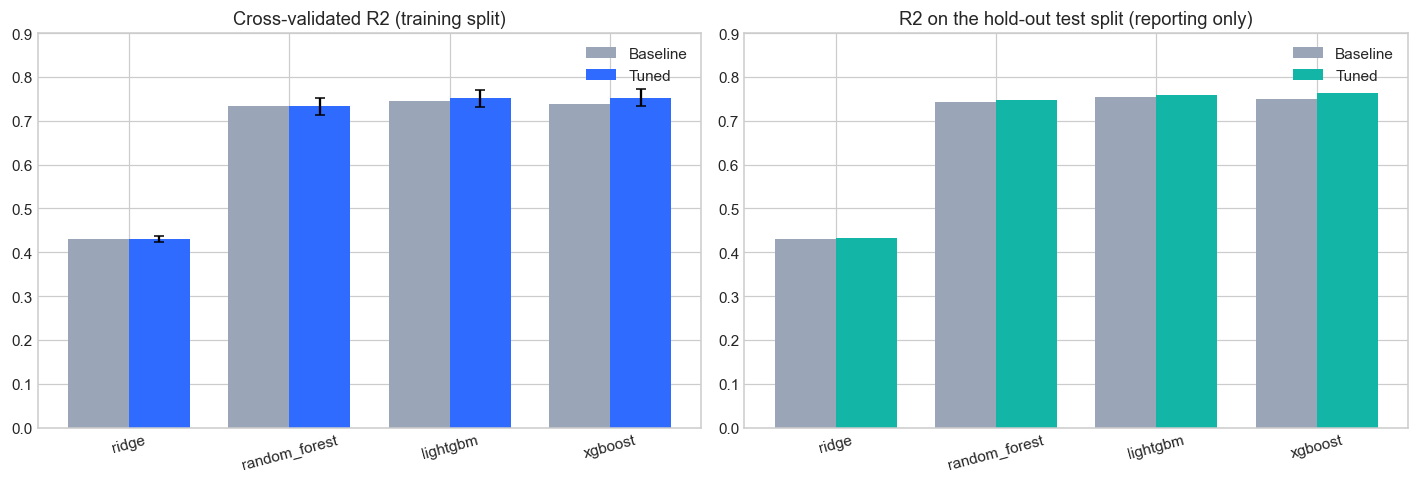

Best settings found:
  ridge          {'alpha': 1.8873918221350976}
  random_forest  {'n_estimators': 150, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 0.9, 'max_depth': 16}
  lightgbm       {'subsample_freq': 1, 'subsample': 1.0, 'reg_lambda': 0, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 10, 'learning_rate': 0.08, 'colsample_bytree': 0.8}
  xgboost        {'subsample': 0.7, 'reg_lambda': 1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.02, 'colsample_bytree': 1.0}


In [17]:
# 7.2 Baseline versus tuned
rows = []
for key in ['ridge', 'random_forest', 'lightgbm', 'xgboost']:
    b, t = results[key]['baseline'], results[key]['tuned']
    rows.append({'Model': key, 'Baseline CV R2': b['cv_r2_mean'], 'Tuned CV R2': t['cv_r2_mean'], 'Tuned CV std': t['cv_r2_std'],
                 'Baseline test R2': b['r2'], 'Tuned test R2': t['r2'], 'Test RMSE ($)': t['rmse'], 'Test MAE ($)': t['mae'], 'Search': t['search']})
tuning_table = pd.DataFrame(rows).set_index('Model')
display(tuning_table.round(4))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(rows)); w = 0.38
ax[0].bar(x - w / 2, tuning_table['Baseline CV R2'], w, label='Baseline', color='#9aa5b8')
ax[0].bar(x + w / 2, tuning_table['Tuned CV R2'], w, yerr=tuning_table['Tuned CV std'], capsize=3, label='Tuned', color='#2F6BFF')
ax[0].set_title('Cross-validated R2 (training split)')
ax[1].bar(x - w / 2, tuning_table['Baseline test R2'], w, label='Baseline', color='#9aa5b8')
ax[1].bar(x + w / 2, tuning_table['Tuned test R2'], w, label='Tuned', color='#12B5A6')
ax[1].set_title('R2 on the hold-out test split (reporting only)')
for a in ax:
    a.set_xticks(x); a.set_xticklabels(tuning_table.index, rotation=15); a.set_ylim(0, 0.9); a.legend()
plt.tight_layout(); plt.show()

print('Best settings found:')
for key in ['ridge', 'random_forest', 'lightgbm', 'xgboost']:
    print(f'  {key:14s}', results[key]['tuned']['best_params'])

### 7.3 Do feature removal or a log-price target help? (ablation)
To check the modelling choices, the tuned XGBoost settings were re-run with parts of the feature set removed and with the log of the price as the target. This takes a few minutes, so the notebook shows the saved results; `03_Models/ablation_experiments.py` reproduces them.

In [18]:
# 7.3 Ablation results (made by 03_Models/ablation_experiments.py)
with open(MODELS / 'ablation_results.json') as f:
    ablation = json.load(f)
pd.DataFrame(ablation).T.rename(columns={'n_features': 'Features', 'cv_r2': 'CV R2', 'test_r2': 'Test R2', 'test_mae': 'Test MAE ($)'})

,Features,CV R2,Test R2,Test MAE ($)
All 57 features (final configuration),57.0,0.7525,0.7628,4688.0
Without Levy,56.0,0.7463,0.7539,4800.0
Without Mileage_per_year,56.0,0.7548,0.7609,4694.0
Without Is_Turbo and Is_Luxury_Make,55.0,0.7351,0.7228,4926.0
Without colour dummies,49.0,0.7530,0.7598,4698.0
Without Age and Mileage_per_year,55.0,0.6500,0.6453,5859.0
Log-price target (all features),57.0,0.7096,0.7088,4860.0


**Result**: no removal improved the cross-validated R², and predicting `log(Price)` was clearly worse (CV R² about 0.71 against 0.75), so the final model keeps all 57 features and the raw price as the target.

---
# Stage 8: Progress Evaluation 2 - Final Model Evaluation

Progress Evaluation 2 (individual viva) covers modelling. The cells below choose the final model by the fixed rule and evaluate it once on the hold-out test split.

In [ ]:
# 8.1 Final model chosen by the pre-set rule: highest cross-validated R2 on the training split
ranking = pd.Series({k: results[k]['tuned']['cv_r2_mean'] for k in results}).sort_values(ascending=False)
print('Cross-validated R2 ranking:')
print(ranking.round(4).to_string())
champion = ranking.index[0]
print(f'\nFinal model: {champion}')

final_model = fitted[champion]
pred = np.clip(final_model.predict(X_test), 500, 150000)       # the service keeps predictions inside the training price range
y = y_test.to_numpy()
print(f'Hold-out test split ({len(y):,} cars): R2 {r2_score(y, pred):.4f} | RMSE ${np.sqrt(mean_squared_error(y, pred)):,.0f} | MAE ${mean_absolute_error(y, pred):,.0f}')
ape = np.abs(pred - y) / y
print(f'Within 15% of the real price: {np.mean(ape <= 0.15):.0%} | within 25%: {np.mean(ape <= 0.25):.0%} | median error {np.median(ape):.0%}')

Cross-validated R2 ranking:
xgboost          0.7525
lightgbm         0.7512
random_forest    0.7334
ridge            0.4304

Final model: xgboost
Hold-out test split (2,803 cars): R2 0.7628 | RMSE $8,150 | MAE $4,688
Within 15% of the real price: 45% | within 25%: 64% | median error 17%


In [ ]:
# 8.2 All four models on the test split + the 80% price range used by the website
metrics = {'champion': champion, 'selection_rule': 'highest 5-fold CV R2 on the training split', 'models': {}}
for key, model in fitted.items():
    p = np.clip(model.predict(X_test), 500, 150000)
    metrics['models'][key] = {
        'test_r2': round(float(r2_score(y, p)), 4), 'test_rmse': round(float(np.sqrt(mean_squared_error(y, p))), 2),
        'test_mae': round(float(mean_absolute_error(y, p)), 2),
        'cv_r2': round(results[key]['tuned']['cv_r2_mean'], 4), 'cv_r2_std': round(results[key]['tuned']['cv_r2_std'], 4)}
    if key == champion:
        lo, hi = np.percentile(y / p, [10, 90])        # actual / predicted: the middle 80% of test cars
        metrics['interval'] = {'coverage': 0.8, 'ratio_low': round(float(lo), 3), 'ratio_high': round(float(hi), 3), 'test_vehicles': int(len(y))}

display(pd.DataFrame(metrics['models']).T)
print('80% range for the champion: estimate x', metrics['interval']['ratio_low'], 'to estimate x', metrics['interval']['ratio_high'])

with open(MODELS / 'model_metrics.json') as f:
    saved_metrics = json.load(f)
print('Same as the saved 03_Models/model_metrics.json (used by the website):', saved_metrics == metrics)
if RUN_SEARCH:
    with open(MODELS / 'model_metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2)

,test_r2,test_rmse,test_mae,cv_r2,cv_r2_std
ridge,0.4431,12489.25,8167.49,0.4304,0.0071
random_forest,0.7477,8405.82,4803.44,0.7334,0.0194
lightgbm,0.7597,8203.94,4819.14,0.7512,0.0195
xgboost,0.7628,8150.29,4688.29,0.7525,0.0192


80% range for the champion: estimate x 0.565 to estimate x 1.382
Same as the saved 03_Models/model_metrics.json (used by the website): True


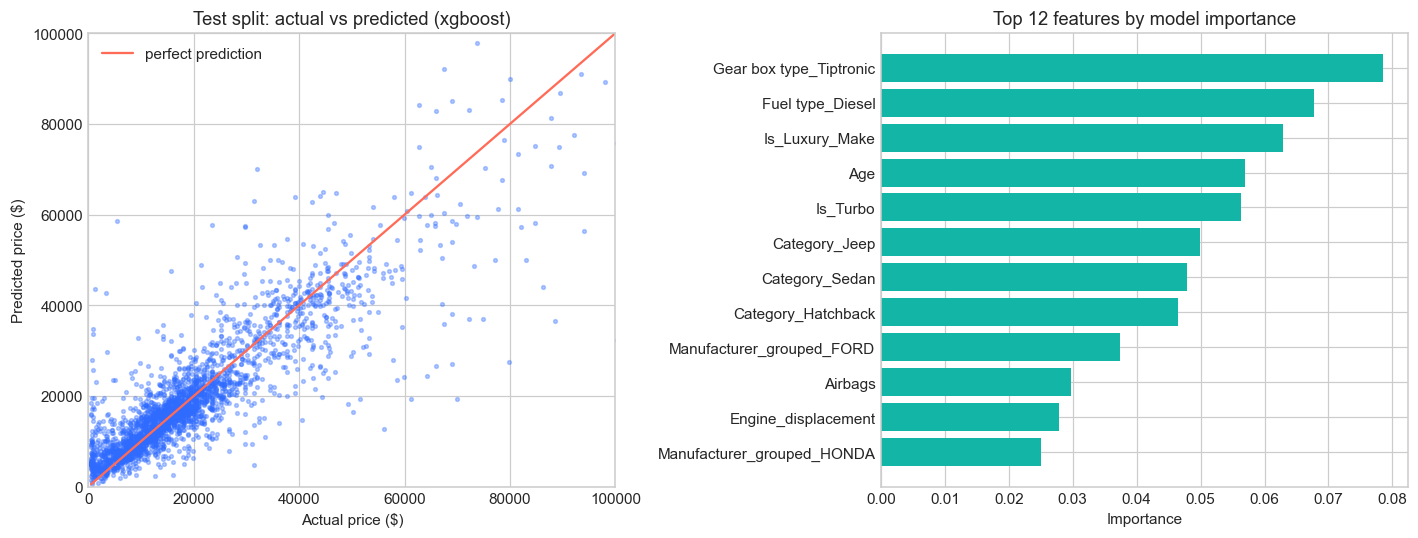

,cars,mean_abs_error_usd,median_pct_error
band,,,
under $3k,190,6019.71,3.55
$3k-8k,384,2806.63,0.26
$8k-15k,737,2768.49,0.17
$15k-30k,990,3859.96,0.13
over $30k,502,10075.81,0.15


In [ ]:
# 8.3 Where the model is accurate and where it is not
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(y, pred, s=6, alpha=0.35, color='#2F6BFF')
ax[0].plot([500, 100000], [500, 100000], color='#FF6B57', lw=1.5, label='perfect prediction')
ax[0].set_xlim(0, 100000); ax[0].set_ylim(0, 100000)
ax[0].set_xlabel('Actual price ($)'); ax[0].set_ylabel('Predicted price ($)'); ax[0].set_title(f'Test split: actual vs predicted ({champion})'); ax[0].legend()

names = np.array(features)
order = np.argsort(final_model.feature_importances_)[::-1][:12][::-1]
ax[1].barh(names[order], final_model.feature_importances_[order], color='#12B5A6')
ax[1].set_title('Top 12 features by model importance'); ax[1].set_xlabel('Importance')
plt.tight_layout(); plt.show()

bands = pd.cut(y, [0, 3000, 8000, 15000, 30000, 1e9], labels=['under $3k', '$3k-8k', '$8k-15k', '$15k-30k', 'over $30k'])
band_table = pd.DataFrame({'band': bands, 'abs_error': np.abs(pred - y), 'ape': np.abs(pred - y) / y}).groupby('band', observed=True).agg(
    cars=('abs_error', 'size'), mean_abs_error_usd=('abs_error', 'mean'), median_pct_error=('ape', 'median'))
band_table.round(2)

### Findings of Stages 6-8
* **XGBoost** is the final model: it has the highest cross-validated R² (about 0.75) and on the unseen test cars explains about **76%** of the price differences with an average error of about **$4,700**. LightGBM and Random Forest are very close, so the choice between the three is a narrow one; Ridge is far behind (about 43%).
* **Age** is by far the most important factor, followed by equipment (airbags), engine size and gear box.
* **Known limit**: very cheap cars (under about $3,000) have large *relative* errors, because those listings often do not follow the car's specification. The website therefore shows a **range** next to every estimate.

